# SANAD — Stage 2, Experiment C
## Reranker Model Comparison after the Corrected Experiment B

### Corrected Experiment C design

Experiment B showed that **Dense Retrieval (BGE-M3 + FAISS)** is stronger than the tested Hybrid (Dense + BM25 RRF) configuration.

Therefore, Experiment C must use the **Dense Top-10 candidates**, not the old Hybrid Top-10 candidates.

### Models compared
- **BAAI/bge-reranker-v2-m3**
- **Qwen/Qwen3-Reranker-0.6B**

### Fair comparison
Both rerankers receive:
- the same 60 test queries
- the same Dense Top-10 candidates
- the same full legal article text
- the same gold labels
- the same metrics

### Metrics
- Recall@3
- Recall@5
- MRR@10
- Candidate Recall@10
- Average reranking time/query

> MRR is reported as **MRR@10** here because the rerankers can only reorder the 10 retrieved candidates. If the gold article is not in the Dense Top-10, neither reranker can recover it.


## 1. Install libraries

In [22]:
!pip install -q -U faiss-cpu pyarrow openpyxl accelerate transformers "sentence-transformers>=5.4.0" FlagEmbedding

## 2. Upload the required files

In [23]:
from google.colab import files
import os

print("Upload these files:")
print("1) saudi_legal_moj_clean.parquet")
print("2) SANAD_Retrieval_Test_Set_60.xlsx")
print("3) bge_m3_saudi_legal.index  <-- corrected BGE index")

uploaded = files.upload()

print("\nFiles in /content:")
print(os.listdir("/content"))


Upload these files:
1) saudi_legal_moj_clean.parquet
2) SANAD_Retrieval_Test_Set_60.xlsx
3) bge_m3_saudi_legal.index  <-- corrected BGE index


Saving bge_m3_saudi_legal.index to bge_m3_saudi_legal (1).index
Saving SANAD_Retrieval_Test_Set_60.xlsx to SANAD_Retrieval_Test_Set_60 (1).xlsx
Saving saudi_legal_moj_clean.parquet to saudi_legal_moj_clean (1).parquet

Files in /content:
['.config', 'SANAD_Experiment_C_Per_Query.csv', 'SANAD_Retrieval_Test_Set_60 (1).xlsx', 'drive', 'saudi_legal_moj_clean.parquet', 'bge_m3_saudi_legal.index', 'saudi_legal_moj_clean (1).parquet', 'bge_m3_saudi_legal (1).index', 'SANAD_Experiment_C_Reranker_Comparison.xlsx', 'augmented_context_FINAL.csv', 'SANAD_Retrieval_Test_Set_60.xlsx', 'sample_data']


## 3. Load and verify data

In [24]:
import pandas as pd
import numpy as np
import faiss

DATA_PATH = "/content/saudi_legal_moj_clean.parquet"
TEST_PATH = "/content/SANAD_Retrieval_Test_Set_60.xlsx"
INDEX_PATH = "/content/bge_m3_saudi_legal.index"

df = pd.read_parquet(DATA_PATH).reset_index(drop=True)
test_df = pd.read_excel(TEST_PATH, sheet_name="Test_Set")
dense_index = faiss.read_index(INDEX_PATH)

print("Dataset rows:", len(df))
print("Test queries:", len(test_df))
print("Dense index vectors:", dense_index.ntotal)
print("Vector dimension:", dense_index.d)

assert len(df) == dense_index.ntotal
assert len(test_df) == 60

print("Verification passed ✅")


Dataset rows: 4226
Test queries: 60
Dense index vectors: 4226
Vector dimension: 1024
Verification passed ✅


## 4. Dense Retrieval — generate the Top-10 candidate pool

This is the only retrieval source used in the corrected Experiment C.

The query embedding setup matches Experiment A/B:
**BGE-M3 query embedding + corrected BGE FAISS index**.


In [25]:
import torch
from sentence_transformers import SentenceTransformer
from tqdm.auto import tqdm
import time

device = "cuda" if torch.cuda.is_available() else "cpu"

dense_model = SentenceTransformer(
    "BAAI/bge-m3",
    device=device
)
dense_model.max_seq_length = 2048

print("Dense embedding model loaded ✅")
print("Device:", device)

# Warm-up
_ = dense_model.encode(
    ["ما حقوق العامل؟"],
    normalize_embeddings=True
)


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/15.8k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/54.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/687 [00:00<?, ?B/s]

...

tokenizer.json: reconstructing file:   0%|          |  0.00B / 17.1MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

Dense embedding model loaded ✅
Device: cuda


In [26]:
TOP_K = 10

candidate_rows = []

for _, row in tqdm(
    test_df.iterrows(),
    total=len(test_df),
    desc="Generating Dense Top-10"
):
    query = str(row["query"])

    start = time.perf_counter()

    q_emb = dense_model.encode(
        [query],
        normalize_embeddings=True
    )
    q_emb = np.asarray(q_emb, dtype="float32")

    scores, indices = dense_index.search(q_emb, TOP_K)

    retrieval_time = time.perf_counter() - start

    candidate_rows.append({
        "query_id": row["query_id"],
        "query_type": row["query_type"],
        "query": query,
        "gold_law": str(row["gold_law"]).strip(),
        "gold_article": str(row["gold_article"]).strip(),
        "candidate_indices": indices[0].astype(int).tolist(),
        "dense_scores": scores[0].astype(float).tolist(),
        "dense_retrieval_time_s": retrieval_time,
    })

candidates_df = pd.DataFrame(candidate_rows)

print("Candidate pools created:", len(candidates_df))
display(candidates_df.head(2))


Generating Dense Top-10:   0%|          | 0/60 [00:00<?, ?it/s]

Candidate pools created: 60


,query_id,query_type,query,gold_law,gold_article,candidate_indices,dense_scores,dense_retrieval_time_s
0,Q001,formal_direct,ما الدعاوى والطلبات التي لا تسري عليها أحكام ا...,نظام التكاليف القضائية,المادة الثانية,"[967, 2305, 1078, 816, 371, 1088, 474, 970, 22...","[0.6747573018074036, 0.6637061238288879, 0.654...",0.095993
1,Q002,formal_paraphrase,ما الحالات المستثناة من تطبيق نظام التكاليف ال...,نظام التكاليف القضائية,المادة الثانية,"[967, 816, 2305, 371, 1078, 2241, 1573, 3347, ...","[0.7080899477005005, 0.6667654514312744, 0.643...",0.040477


## 5. Verify the Dense baseline inside the Top-10 candidate set

In [27]:
def is_gold(doc_idx, gold_law, gold_article):
    row = df.iloc[int(doc_idx)]
    return (
        str(row["law_name"]).strip() == str(gold_law).strip()
        and str(row["article_number"]).strip() == str(gold_article).strip()
    )

def gold_rank_from_indices(indices, gold_law, gold_article):
    for rank, idx in enumerate(indices, start=1):
        if is_gold(idx, gold_law, gold_article):
            return rank
    return None

def metrics_at_10(rank):
    return {
        "Recall@3": int(rank is not None and rank <= 3),
        "Recall@5": int(rank is not None and rank <= 5),
        "Recall@10": int(rank is not None and rank <= 10),
        "RR@10": (1 / rank) if rank is not None else 0.0,
    }

baseline_rows = []

for _, row in candidates_df.iterrows():
    rank = gold_rank_from_indices(
        row["candidate_indices"],
        row["gold_law"],
        row["gold_article"]
    )
    m = metrics_at_10(rank)

    baseline_rows.append({
        "query_id": row["query_id"],
        "query_type": row["query_type"],
        "Dense_Gold_Rank@10": rank,
        "Dense_Recall@3": m["Recall@3"],
        "Dense_Recall@5": m["Recall@5"],
        "Dense_Recall@10": m["Recall@10"],
        "Dense_RR@10": m["RR@10"],
    })

baseline_df = pd.DataFrame(baseline_rows)

dense_summary = pd.DataFrame([{
    "Method": "Dense before reranking",
    "Recall@3": baseline_df["Dense_Recall@3"].mean(),
    "Recall@5": baseline_df["Dense_Recall@5"].mean(),
    "Recall@10": baseline_df["Dense_Recall@10"].mean(),
    "MRR@10": baseline_df["Dense_RR@10"].mean(),
}])

display(dense_summary)


,Method,Recall@3,Recall@5,Recall@10,MRR@10
0,Dense before reranking,0.783333,0.85,0.9,0.708426


## 6. Build the reranker passages

Both rerankers receive the **same full legal article text** for every candidate.


In [28]:
def candidate_text(doc_idx):
    return str(df.iloc[int(doc_idx)]["text"])

# Example
example_idx = candidates_df.iloc[0]["candidate_indices"][0]
print(candidate_text(example_idx)[:800])


المادة السابعةعشرة
مع مراعاة ما تقضي به الأنظمة والمعاهدات والاتفاقيات الدولية التي تكون المملكة طرفاًء لا تفرض التكاليف القضائية على الفئاتالآتية:
١.المسجونون والموقوفون وقت استحقاق التكاليف القضائية في قضايا مالية غير جنائية» في الدعاوى التي تقام سواءً كانت منهم أوعليهم.
".العمال المشمولون بنظام العمل والمستثنون منه والمستحقون عنهم؛ للمطالبة بمستحقاتهم الناشئة عن عقودعمل.
“.الوزارات والأجهزةالحكومية.
وتحدد اللائحة الإجراءات والقواعد الخاصةبذلك.


## 7. Free the embedding model before reranking

This reduces GPU memory usage in Colab.


In [29]:
import gc

del dense_model
gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("Dense embedding model released ✅")


Dense embedding model released ✅


# Part A — BGE reranker

Official model: `BAAI/bge-reranker-v2-m3`

For each query, the reranker scores the same 10 `(query, full article text)` pairs.
Higher score = more relevant.


In [30]:
from FlagEmbedding import FlagReranker

bge_reranker = FlagReranker(
    "BAAI/bge-reranker-v2-m3",
    use_fp16=torch.cuda.is_available()
)

print("BGE reranker loaded ✅")


config.json:   0%|          | 0.00/795 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.17k [00:00<?, ?B/s]

sentencepiece.bpe.model: reconstructing file:   0%|          |  0.00B / 5.07MB            

sentencepiece.bpe.model: downloading bytes:           |  0.00B            

tokenizer.json: reconstructing file:   0%|          |  0.00B / 17.1MB            

...

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 2.27GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

BGE reranker loaded ✅


In [31]:
bge_results = []

for _, row in tqdm(
    candidates_df.iterrows(),
    total=len(candidates_df),
    desc="BGE reranking"
):
    query = row["query"]
    candidate_indices = row["candidate_indices"]

    pairs = [
        [query, candidate_text(idx)]
        for idx in candidate_indices
    ]

    start = time.perf_counter()

    scores = bge_reranker.compute_score(
        pairs,
        normalize=True
    )

    elapsed = time.perf_counter() - start

    scores = np.asarray(scores, dtype=float).reshape(-1)
    order = np.argsort(-scores, kind="stable")

    reranked_indices = [
        int(candidate_indices[i]) for i in order
    ]
    reranked_scores = [
        float(scores[i]) for i in order
    ]

    gold_rank = gold_rank_from_indices(
        reranked_indices,
        row["gold_law"],
        row["gold_article"]
    )
    m = metrics_at_10(gold_rank)

    result = {
        "query_id": row["query_id"],
        "query_type": row["query_type"],
        "BGE_Gold_Rank@10": gold_rank,
        "BGE_Recall@3": m["Recall@3"],
        "BGE_Recall@5": m["Recall@5"],
        "BGE_Recall@10": m["Recall@10"],
        "BGE_RR@10": m["RR@10"],
        "BGE_Time_s": elapsed,
        "BGE_Reranked_Indices": reranked_indices,
        "BGE_Reranked_Scores": reranked_scores,
    }

    bge_results.append(result)

bge_df = pd.DataFrame(bge_results)

print("BGE reranking finished ✅")


BGE reranking:   0%|          | 0/60 [00:00<?, ?it/s]

BGE reranking finished ✅


## 8. Free BGE reranker before loading Qwen

In [32]:
del bge_reranker
gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("BGE reranker released ✅")


BGE reranker released ✅


# Part B — Qwen3 reranker

Official model: `Qwen/Qwen3-Reranker-0.6B`

This notebook uses the current Sentence Transformers `CrossEncoder` interface supported by the model.


In [33]:
from sentence_transformers import CrossEncoder

qwen_reranker = CrossEncoder(
    "Qwen/Qwen3-Reranker-0.6B",
    device=device
)

print("Qwen3 reranker loaded ✅")


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Qwen3 reranker loaded ✅


In [34]:
from sentence_transformers import CrossEncoder

qwen_reranker = CrossEncoder(
    "Qwen/Qwen3-Reranker-0.6B",
    device=device
)

print("✅ Qwen loaded on:", device)

Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

✅ Qwen loaded on: cuda


In [35]:
qwen_results = []

for _, row in tqdm(
    candidates_df.iterrows(),
    total=len(candidates_df),
    desc="Qwen3 reranking"
):
    query = row["query"]
    candidate_indices = row["candidate_indices"]

    pairs = [
        (query, candidate_text(idx))
        for idx in candidate_indices
    ]

    start = time.perf_counter()

    scores = qwen_reranker.predict(
        pairs,
        batch_size=10,
        show_progress_bar=False
    )

    elapsed = time.perf_counter() - start

    scores = np.asarray(scores, dtype=float).reshape(-1)
    order = np.argsort(-scores, kind="stable")

    reranked_indices = [
        int(candidate_indices[i]) for i in order
    ]
    reranked_scores = [
        float(scores[i]) for i in order
    ]

    gold_rank = gold_rank_from_indices(
        reranked_indices,
        row["gold_law"],
        row["gold_article"]
    )
    m = metrics_at_10(gold_rank)

    result = {
        "query_id": row["query_id"],
        "query_type": row["query_type"],
        "Qwen_Gold_Rank@10": gold_rank,
        "Qwen_Recall@3": m["Recall@3"],
        "Qwen_Recall@5": m["Recall@5"],
        "Qwen_Recall@10": m["Recall@10"],
        "Qwen_RR@10": m["RR@10"],
        "Qwen_Time_s": elapsed,
        "Qwen_Reranked_Indices": reranked_indices,
        "Qwen_Reranked_Scores": reranked_scores,
    }

    qwen_results.append(result)

qwen_df = pd.DataFrame(qwen_results)

print("Qwen3 reranking finished ✅")


Qwen3 reranking:   0%|          | 0/60 [00:00<?, ?it/s]

Qwen3 reranking finished ✅


## 9. Overall comparison

In [36]:
merged = (
    candidates_df
    .merge(baseline_df, on=["query_id", "query_type"])
    .merge(bge_df, on=["query_id", "query_type"])
    .merge(qwen_df, on=["query_id", "query_type"])
)

overall_df = pd.DataFrame([
    {
        "Method": "Dense before reranking",
        "Recall@3": merged["Dense_Recall@3"].mean(),
        "Recall@5": merged["Dense_Recall@5"].mean(),
        "Recall@10": merged["Dense_Recall@10"].mean(),
        "MRR@10": merged["Dense_RR@10"].mean(),
        "Avg_Rerank_Time_s": np.nan,
    },
    {
        "Method": "BGE-reranker-v2-m3",
        "Recall@3": merged["BGE_Recall@3"].mean(),
        "Recall@5": merged["BGE_Recall@5"].mean(),
        "Recall@10": merged["BGE_Recall@10"].mean(),
        "MRR@10": merged["BGE_RR@10"].mean(),
        "Avg_Rerank_Time_s": merged["BGE_Time_s"].mean(),
    },
    {
        "Method": "Qwen3-Reranker-0.6B",
        "Recall@3": merged["Qwen_Recall@3"].mean(),
        "Recall@5": merged["Qwen_Recall@5"].mean(),
        "Recall@10": merged["Qwen_Recall@10"].mean(),
        "MRR@10": merged["Qwen_RR@10"].mean(),
        "Avg_Rerank_Time_s": merged["Qwen_Time_s"].mean(),
    }
])

display(overall_df)


,Method,Recall@3,Recall@5,Recall@10,MRR@10,Avg_Rerank_Time_s
0,Dense before reranking,0.783333,0.850000,0.9,0.708426,NaN
1,BGE-reranker-v2-m3,0.816667,0.866667,0.9,0.781667,0.274312
2,Qwen3-Reranker-0.6B,0.833333,0.850000,0.9,0.787407,2.255878


## 10. Results by query type

In [37]:
type_rows = []

for query_type, group in merged.groupby("query_type"):
    type_rows.extend([
        {
            "query_type": query_type,
            "Method": "Dense before reranking",
            "Recall@3": group["Dense_Recall@3"].mean(),
            "Recall@5": group["Dense_Recall@5"].mean(),
            "Recall@10": group["Dense_Recall@10"].mean(),
            "MRR@10": group["Dense_RR@10"].mean(),
        },
        {
            "query_type": query_type,
            "Method": "BGE-reranker-v2-m3",
            "Recall@3": group["BGE_Recall@3"].mean(),
            "Recall@5": group["BGE_Recall@5"].mean(),
            "Recall@10": group["BGE_Recall@10"].mean(),
            "MRR@10": group["BGE_RR@10"].mean(),
        },
        {
            "query_type": query_type,
            "Method": "Qwen3-Reranker-0.6B",
            "Recall@3": group["Qwen_Recall@3"].mean(),
            "Recall@5": group["Qwen_Recall@5"].mean(),
            "Recall@10": group["Qwen_Recall@10"].mean(),
            "MRR@10": group["Qwen_RR@10"].mean(),
        },
    ])

by_type_df = pd.DataFrame(type_rows)
display(by_type_df)


,query_type,Method,Recall@3,Recall@5,Recall@10,MRR@10
0,formal_direct,Dense before reranking,0.90,0.90,0.9,0.791667
1,formal_direct,BGE-reranker-v2-m3,0.90,0.90,0.9,0.825000
2,formal_direct,Qwen3-Reranker-0.6B,0.90,0.90,0.9,0.875000
3,formal_paraphrase,Dense before reranking,0.75,0.85,0.9,0.653056
4,formal_paraphrase,BGE-reranker-v2-m3,0.75,0.85,0.9,0.752500
5,formal_paraphrase,Qwen3-Reranker-0.6B,0.85,0.85,0.9,0.800000
6,informal,Dense before reranking,0.70,0.80,0.9,0.680556
7,informal,BGE-reranker-v2-m3,0.80,0.85,0.9,0.767500
8,informal,Qwen3-Reranker-0.6B,0.75,0.80,0.9,0.687222


## 11. Win / tie / loss based on gold rank

This shows how often each reranker actually moves the correct article up or down relative to the Dense Top-10 ranking.


In [38]:
def compare_rank(before, after):
    before = 10**9 if pd.isna(before) else int(before)
    after = 10**9 if pd.isna(after) else int(after)

    if after < before:
        return "Better"
    if after > before:
        return "Worse"
    return "Same"

merged["BGE_vs_Dense"] = merged.apply(
    lambda r: compare_rank(r["Dense_Gold_Rank@10"], r["BGE_Gold_Rank@10"]),
    axis=1
)

merged["Qwen_vs_Dense"] = merged.apply(
    lambda r: compare_rank(r["Dense_Gold_Rank@10"], r["Qwen_Gold_Rank@10"]),
    axis=1
)

win_loss_df = pd.DataFrame({
    "BGE reranker": merged["BGE_vs_Dense"].value_counts(),
    "Qwen reranker": merged["Qwen_vs_Dense"].value_counts(),
}).fillna(0).astype(int)

display(win_loss_df)


,BGE reranker,Qwen reranker
Same,43,41
Better,12,14
Worse,5,5


## 12. Paired bootstrap 95% CI for reranker improvement over Dense

In [39]:
rng = np.random.default_rng(42)
N_BOOT = 5000

def paired_bootstrap(before, after):
    before = np.asarray(before, dtype=float)
    after = np.asarray(after, dtype=float)

    n = len(before)
    observed = after.mean() - before.mean()
    diffs = np.empty(N_BOOT)

    for i in range(N_BOOT):
        idx = rng.integers(0, n, size=n)
        diffs[i] = after[idx].mean() - before[idx].mean()

    lo, hi = np.percentile(diffs, [2.5, 97.5])
    return observed, lo, hi

ci_rows = []

for model_name, prefix in [
    ("BGE-reranker-v2-m3", "BGE"),
    ("Qwen3-Reranker-0.6B", "Qwen"),
]:
    for metric, before_col, after_col in [
        ("Recall@3", "Dense_Recall@3", f"{prefix}_Recall@3"),
        ("Recall@5", "Dense_Recall@5", f"{prefix}_Recall@5"),
        ("MRR@10", "Dense_RR@10", f"{prefix}_RR@10"),
    ]:
        diff, lo, hi = paired_bootstrap(
            merged[before_col],
            merged[after_col]
        )

        ci_rows.append({
            "Model": model_name,
            "Metric": metric,
            "Improvement_over_Dense": diff,
            "95% CI Lower": lo,
            "95% CI Upper": hi,
        })

ci_df = pd.DataFrame(ci_rows)
display(ci_df)


,Model,Metric,Improvement_over_Dense,95% CI Lower,95% CI Upper
0,BGE-reranker-v2-m3,Recall@3,0.033333,-0.033333,0.100000
1,BGE-reranker-v2-m3,Recall@5,0.016667,-0.033333,0.083333
2,BGE-reranker-v2-m3,MRR@10,0.073241,0.014155,0.137315
3,Qwen3-Reranker-0.6B,Recall@3,0.050000,-0.016667,0.133333
4,Qwen3-Reranker-0.6B,Recall@5,0.000000,-0.050000,0.050000
5,Qwen3-Reranker-0.6B,MRR@10,0.078981,0.008146,0.152875


## 13. Comparison chart

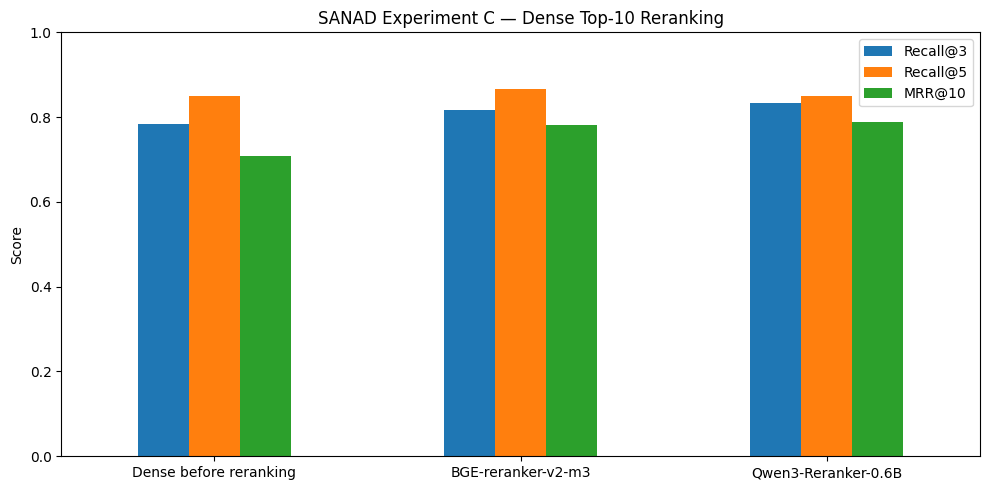

In [40]:
import matplotlib.pyplot as plt

plot_df = overall_df.set_index("Method")[["Recall@3", "Recall@5", "MRR@10"]]

ax = plot_df.plot(
    kind="bar",
    figsize=(10, 5)
)

ax.set_title("SANAD Experiment C — Dense Top-10 Reranking")
ax.set_ylabel("Score")
ax.set_xlabel("")
ax.set_ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 14. Select the reranker from the actual results

Do not hard-code a winner before running the experiment.

Use:
1. Recall@3
2. Recall@5
3. MRR@10
4. query-type behavior
5. latency

If Recall is equal, MRR@10 is a useful tie-breaker because it measures whether the gold article is moved closer to Rank 1.


In [41]:
bge_row = overall_df[overall_df["Method"] == "BGE-reranker-v2-m3"].iloc[0]
qwen_row = overall_df[overall_df["Method"] == "Qwen3-Reranker-0.6B"].iloc[0]

print("BGE reranker:")
print(bge_row)
print("\nQwen reranker:")
print(qwen_row)


BGE reranker:
Method               BGE-reranker-v2-m3
Recall@3                       0.816667
Recall@5                       0.866667
Recall@10                           0.9
MRR@10                         0.781667
Avg_Rerank_Time_s              0.274312
Name: 1, dtype: object

Qwen reranker:
Method               Qwen3-Reranker-0.6B
Recall@3                        0.833333
Recall@5                            0.85
Recall@10                            0.9
MRR@10                          0.787407
Avg_Rerank_Time_s               2.255878
Name: 2, dtype: object


## 15. Build augmented context using the selected reranker

After you inspect the results, set:

`WINNER = "BGE"` or `WINNER = "Qwen"`

The final Top-3 full legal articles will then be combined with the user query.


In [42]:
# Change this only AFTER inspecting the experiment results.
WINNER = "Qwen"   # or "Qwen"

assert WINNER in {"BGE", "Qwen"}

context_rows = []

for _, row in merged.iterrows():
    reranked_indices = row[f"{WINNER}_Reranked_Indices"]

    top3_indices = reranked_indices[:3]

    context_parts = []

    for rank, idx in enumerate(top3_indices, start=1):
        legal_row = df.iloc[int(idx)]

        context_parts.append(
            f"[Retrieved Article {rank}]\n"
            f"Law: {legal_row['law_name']}\n"
            f"Article: {legal_row['article_number']}\n"
            f"Text: {legal_row['text']}"
        )

    augmented_context = (
        f"User Query:\n{row['query']}\n\n"
        + "\n\n".join(context_parts)
    )

    context_rows.append({
        "query_id": row["query_id"],
        "query_type": row["query_type"],
        "query": row["query"],
        "gold_law": row["gold_law"],
        "gold_article": row["gold_article"],
        "selected_reranker": WINNER,
        "augmented_context": augmented_context,
    })

augmented_context_df = pd.DataFrame(context_rows)

display(augmented_context_df.head(2))


,query_id,query_type,query,gold_law,gold_article,selected_reranker,augmented_context
0,Q001,formal_direct,ما الدعاوى والطلبات التي لا تسري عليها أحكام ا...,نظام التكاليف القضائية,المادة الثانية,Qwen,User Query:\nما الدعاوى والطلبات التي لا تسري ...
1,Q002,formal_paraphrase,ما الحالات المستثناة من تطبيق نظام التكاليف ال...,نظام التكاليف القضائية,المادة الثانية,Qwen,User Query:\nما الحالات المستثناة من تطبيق نظا...


## 16. Save all outputs

In [43]:
OUTPUT_XLSX = "/content/SANAD_Experiment_C_Reranker_Comparison.xlsx"
OUTPUT_PER_QUERY = "/content/SANAD_Experiment_C_Per_Query.csv"
OUTPUT_CONTEXT = "/content/augmented_context_FINAL.csv"

with pd.ExcelWriter(OUTPUT_XLSX, engine="openpyxl") as writer:
    overall_df.to_excel(writer, sheet_name="Overall", index=False)
    by_type_df.to_excel(writer, sheet_name="By_Query_Type", index=False)
    win_loss_df.to_excel(writer, sheet_name="Win_Tie_Loss")
    ci_df.to_excel(writer, sheet_name="Bootstrap_CI", index=False)
    merged.to_excel(writer, sheet_name="Per_Query", index=False)

merged.to_csv(
    OUTPUT_PER_QUERY,
    index=False,
    encoding="utf-8-sig"
)

augmented_context_df.to_csv(
    OUTPUT_CONTEXT,
    index=False,
    encoding="utf-8-sig"
)

print("Saved ✅")
print(OUTPUT_XLSX)
print(OUTPUT_PER_QUERY)
print(OUTPUT_CONTEXT)


Saved ✅
/content/SANAD_Experiment_C_Reranker_Comparison.xlsx
/content/SANAD_Experiment_C_Per_Query.csv
/content/augmented_context_FINAL.csv


## 17. Download outputs

In [44]:
from google.colab import files

files.download("/content/SANAD_Experiment_C_Reranker_Comparison.xlsx")
files.download("/content/SANAD_Experiment_C_Per_Query.csv")
files.download("/content/augmented_context_FINAL.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>